## **Import Libraries**

In [58]:
#Core Data Manipulation
import pandas as pd
import numpy as np

In [59]:
#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
#Statistical modelling
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

In [61]:
# Machine learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, 
                           precision_score, recall_score, f1_score, roc_curve, auc, 
                           roc_auc_score, precision_recall_curve, average_precision_score, 
                           matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score)

In [62]:
# Model building and pipelines import
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier # Added import for KNeighborsClassifier
from sklearn.svm import SVC # Added import for SVC
from sklearn.ensemble import RandomForestClassifier

print("Necessary libraries for model building and pipelines imported.")

Necessary libraries for model building and pipelines imported.


In [63]:
# Reproducibility
import warnings
warnings.filterwarnings('ignore')
np.random.seed(2026)

print('Libraries imported. Starting analysis.../n')

Libraries imported. Starting analysis.../n


### **Data Loading and Initial Exploration**

In [64]:
print("="*70)
print("DATA LOADING AND INITIAL EXPLORATION")
print("="*70)

#Loading the Dataset
df = pd.read_csv('htn_dat.csv')

DATA LOADING AND INITIAL EXPLORATION


### **Display Basic Information**

In [65]:
print("\n Display Basic Information")
print(f"\n Dataset shape:{df.shape}")
print(f"\n Column names:{list(df.columns)}")
print(f"\n Missing values:\n{df.isnull().sum()}")



 Display Basic Information

 Dataset shape:(4999, 16)

 Column names:['ID', 'DBP', 'SBP', 'BMI', 'age', 'married', 'male.gender', 'hgb_centered', 'adv_HIV', 'survtime', 'event', 'arv_naive', 'urban.clinic', 'log_creat_centered', 'IPW_weight', 'SBP_ge120']

 Missing values:
ID                       0
DBP                      0
SBP                      0
BMI                    670
age                      0
married                164
male.gender              0
hgb_centered          1394
adv_HIV               1961
survtime                 0
event                    0
arv_naive                0
urban.clinic             0
log_creat_centered    1538
IPW_weight               0
SBP_ge120                0
dtype: int64


In [66]:
print(f"\n First 5 rows:\n{df.head()}")
print(f"\n Last 5 rows:\n{df.tail()}")


 First 5 rows:
      ID  DBP  SBP        BMI        age  married  male.gender  hgb_centered  \
0  16097   60   90        NaN  28.000000      0.0            0           NaN   
1    930   75  110  27.339912  26.458590      1.0            0          -3.9   
2   6877   60   80  17.689789  42.951405      0.0            0          -3.2   
3  36464   60   90  19.854080  50.149212      1.0            1           NaN   
4  36180   60  100  21.295294  30.554415      0.0            1          -0.4   

   adv_HIV  survtime  event  arv_naive  urban.clinic  log_creat_centered  \
0      NaN       338      1          1             0                 NaN   
1      0.0       439      1          1             1        5.421770e-02   
2      NaN       752      1          1             0       -3.597409e-01   
3      NaN       526      1          1             1                 NaN   
4      NaN       215      1          1             0       -1.000000e-07   

   IPW_weight  SBP_ge120  
0    0.924379      

In [67]:
print(f"\n Data types:\n{df.dtypes}")
print(f"\n Summary statistics:\n{df.describe()}")


 Data types:
ID                      int64
DBP                     int64
SBP                     int64
BMI                   float64
age                   float64
married               float64
male.gender             int64
hgb_centered          float64
adv_HIV               float64
survtime                int64
event                   int64
arv_naive               int64
urban.clinic            int64
log_creat_centered    float64
IPW_weight            float64
SBP_ge120               int64
dtype: object

 Summary statistics:
                 ID          DBP          SBP          BMI          age  \
count   4999.000000  4999.000000  4999.000000  4329.000000  4999.000000   
mean   24972.219644    68.030206   110.593919    21.428649    35.191304   
std    14379.942003    10.319607    14.776308     3.619755    10.563761   
min        6.000000    40.000000    65.000000    15.002075    16.024641   
25%    12466.500000    60.000000   100.000000    18.870663    27.197809   
50%    25464.000000 

### **Univariate Analysis**

#### **1.1 Target class Distribution Plot**


 Univariate Analysis

 Target Class Distribution Plot


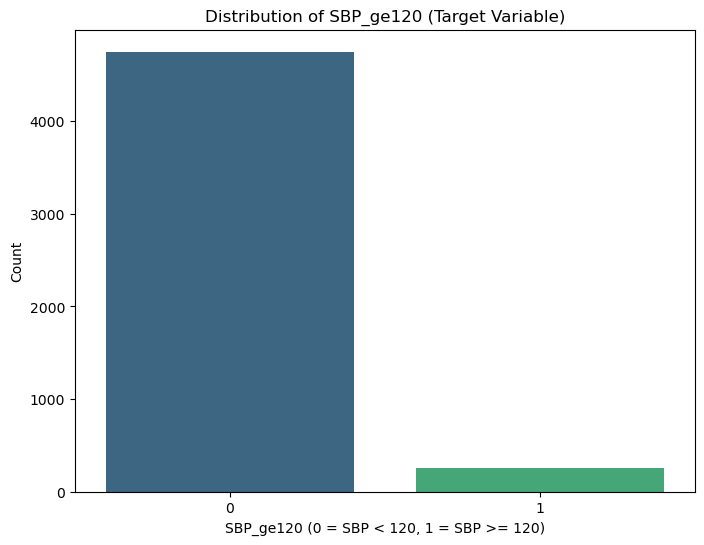

In [68]:
print("\n Univariate Analysis")
print("="*70)
print("\n Target Class Distribution Plot")
plt.figure(figsize=(8, 6))
sns.countplot(x='SBP_ge120', data=df, palette='viridis')
plt.title('Distribution of SBP_ge120 (Target Variable)')
plt.xlabel('SBP_ge120 (0 = SBP < 120, 1 = SBP >= 120)')
plt.ylabel('Count')
# Interpretation: Observe the distribution of the target classes (0 and 1). This plot helps identify if the dataset is imbalanced, which can be crucial for model training.
plt.show()

#### **1.2 Missing Values Heatmap**


 Missing Values Heatmap


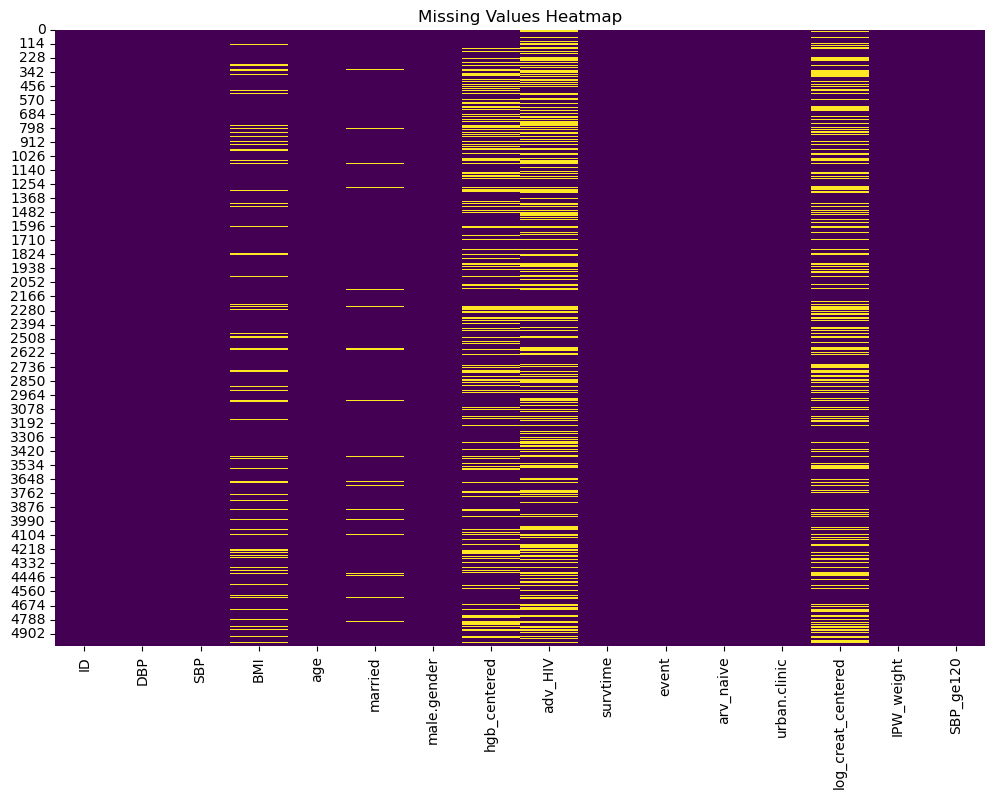

In [69]:
# Creating a missing values heatmap
print("\n Missing Values Heatmap")
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
# Interpretation: Darker areas indicate the presence of missing values, while lighter areas indicate no missing values. This helps to visually identify columns with a high number of missing data points.
plt.show()

### **1.3 Numerical Feature Distributions (Histograms and Boxplots)**

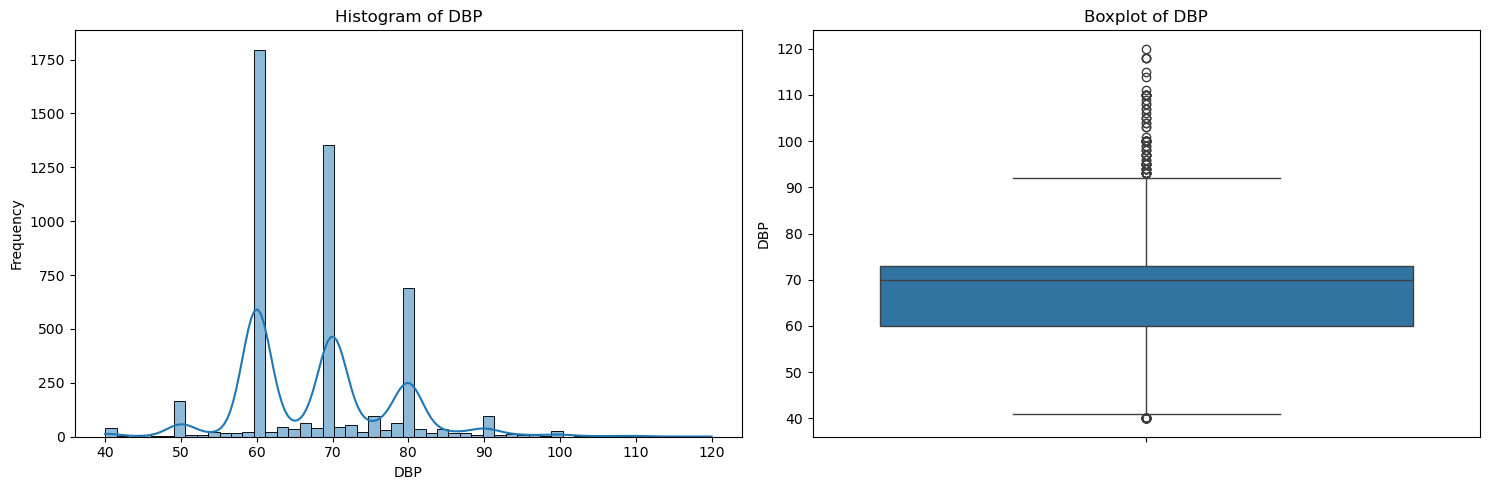

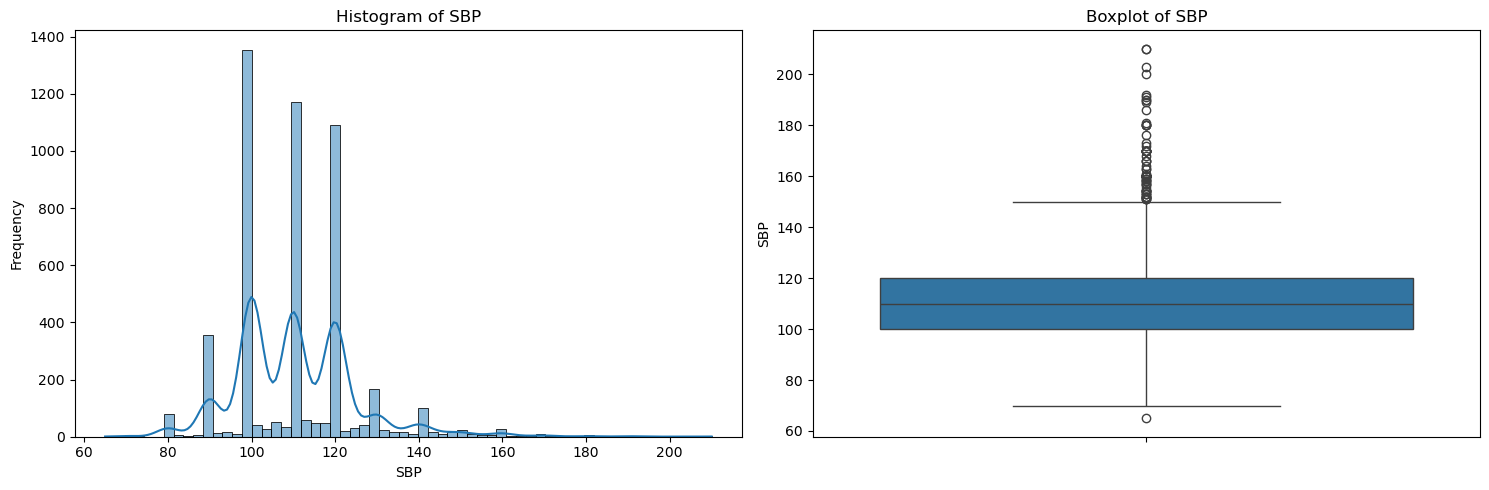

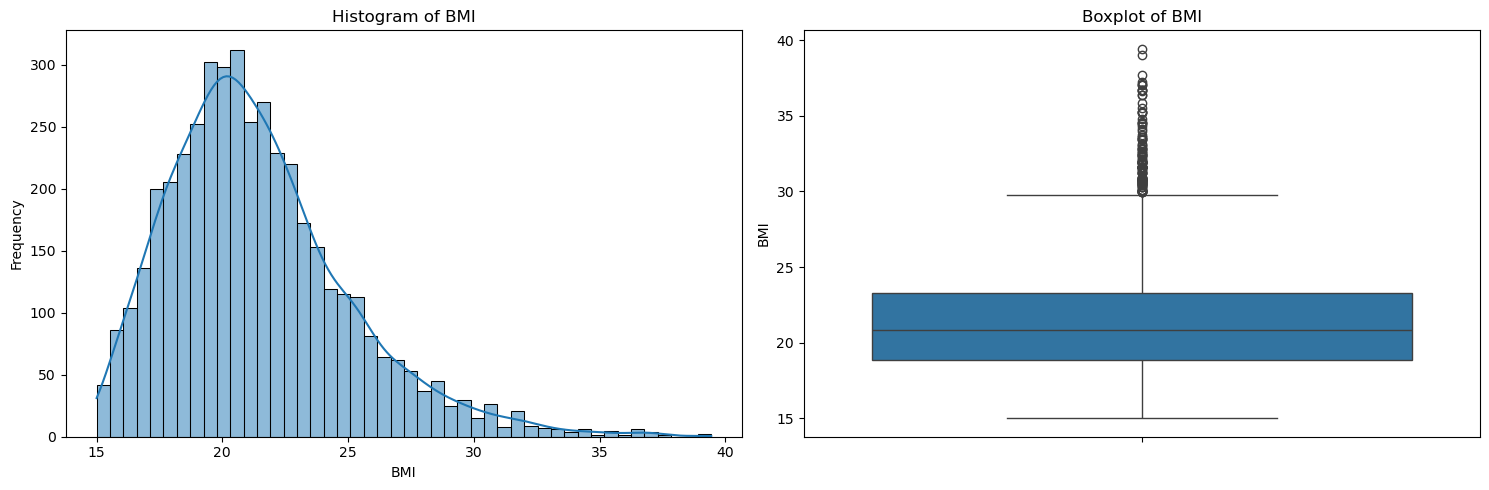

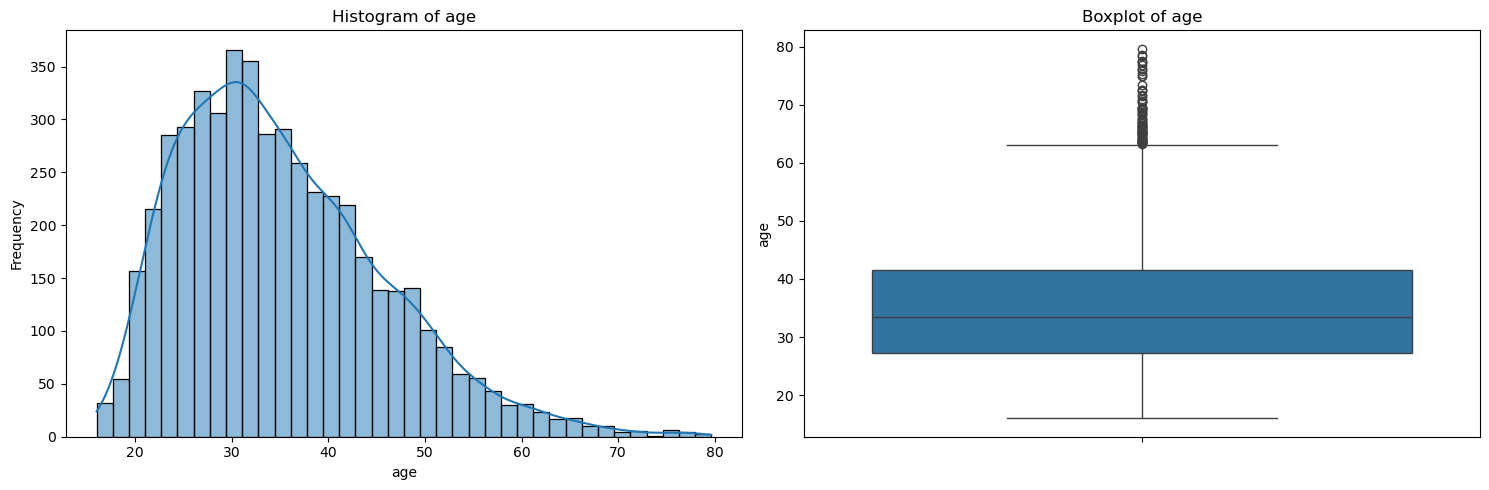

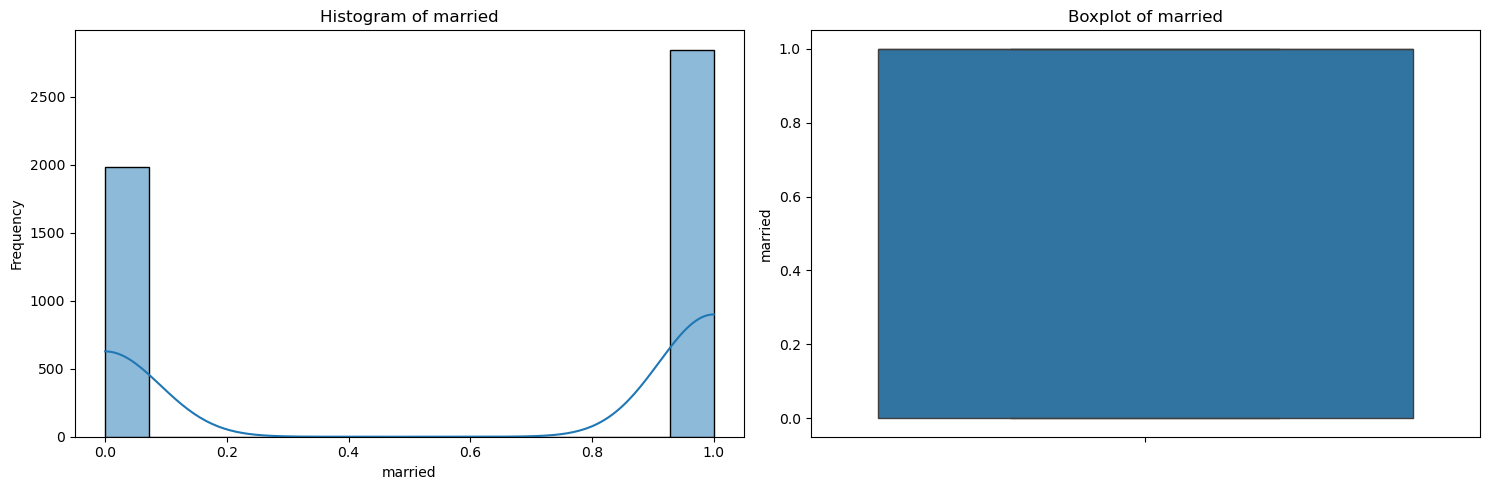

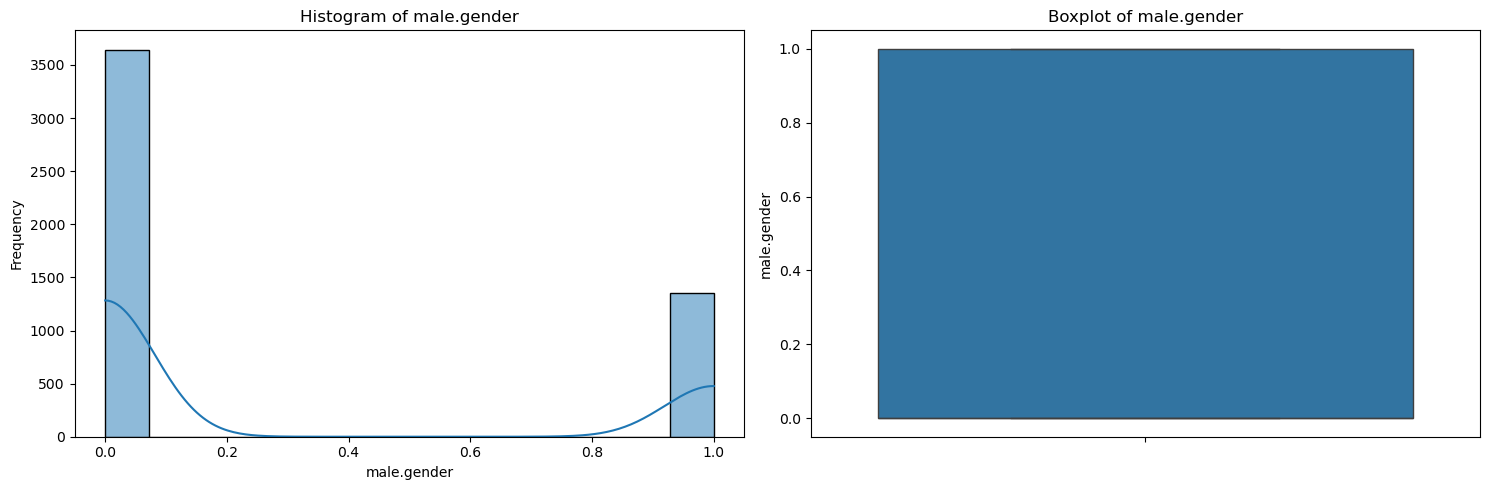

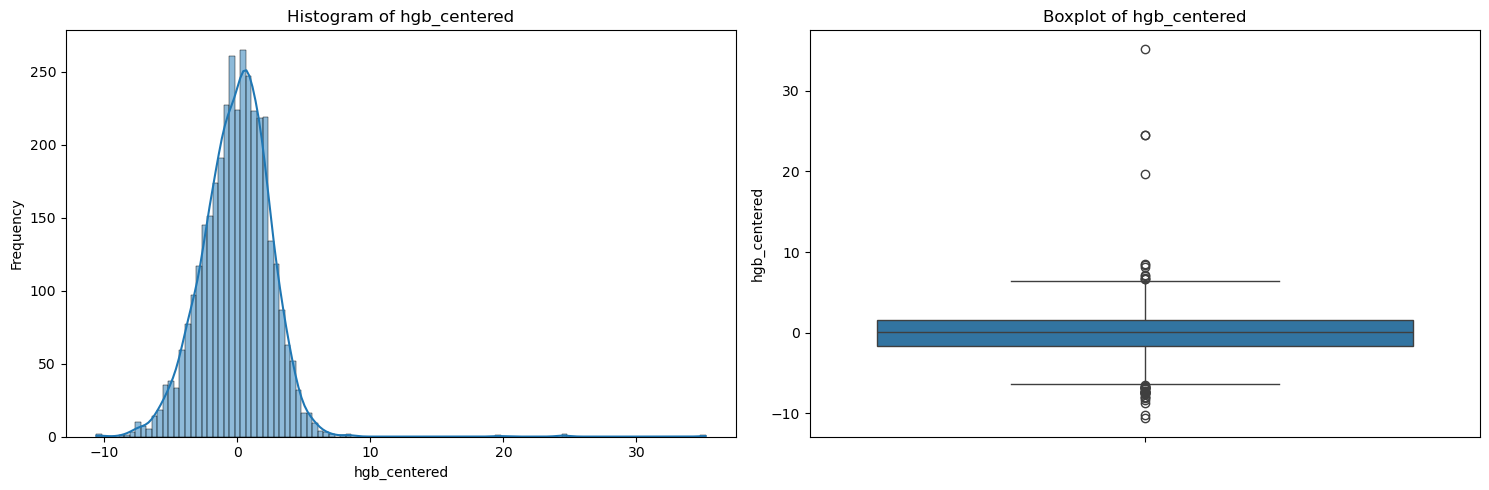

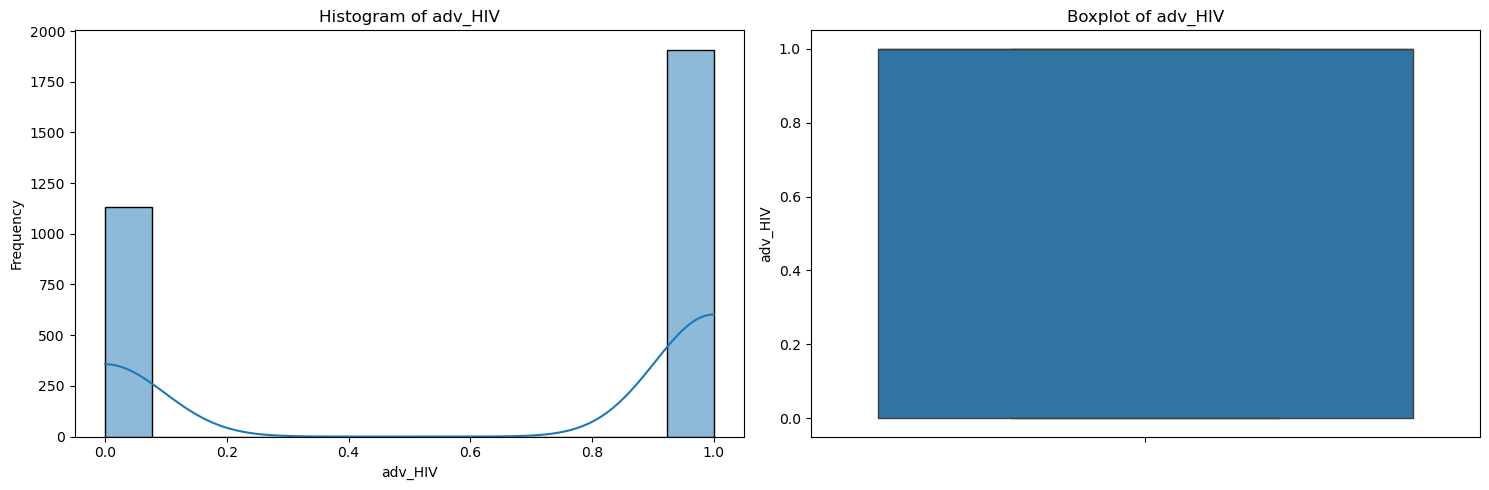

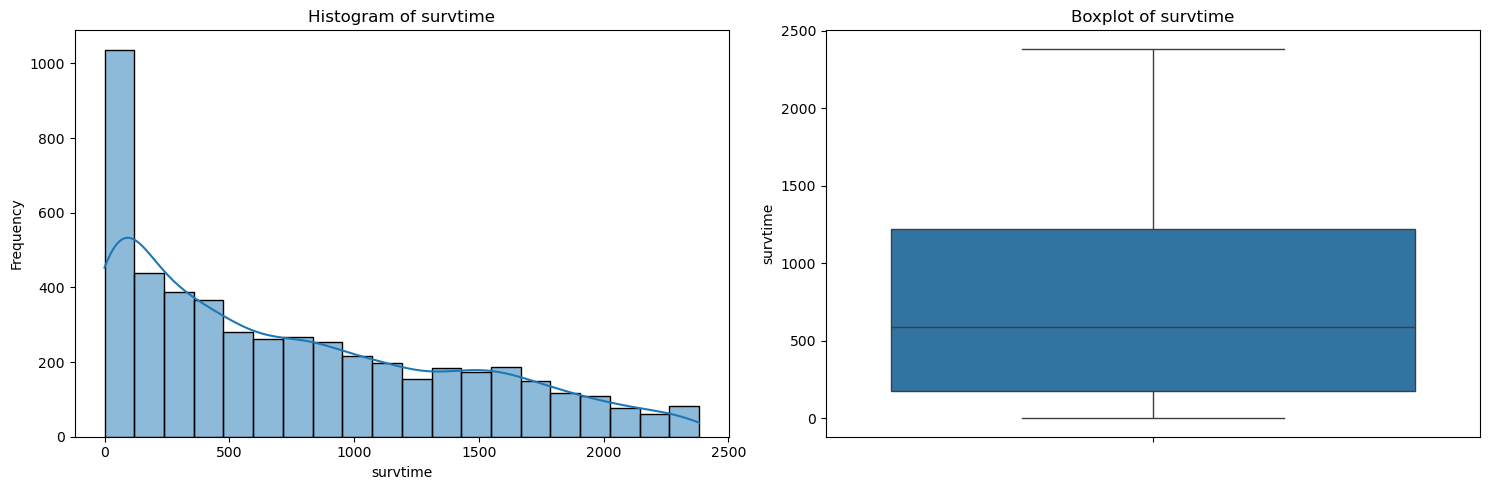

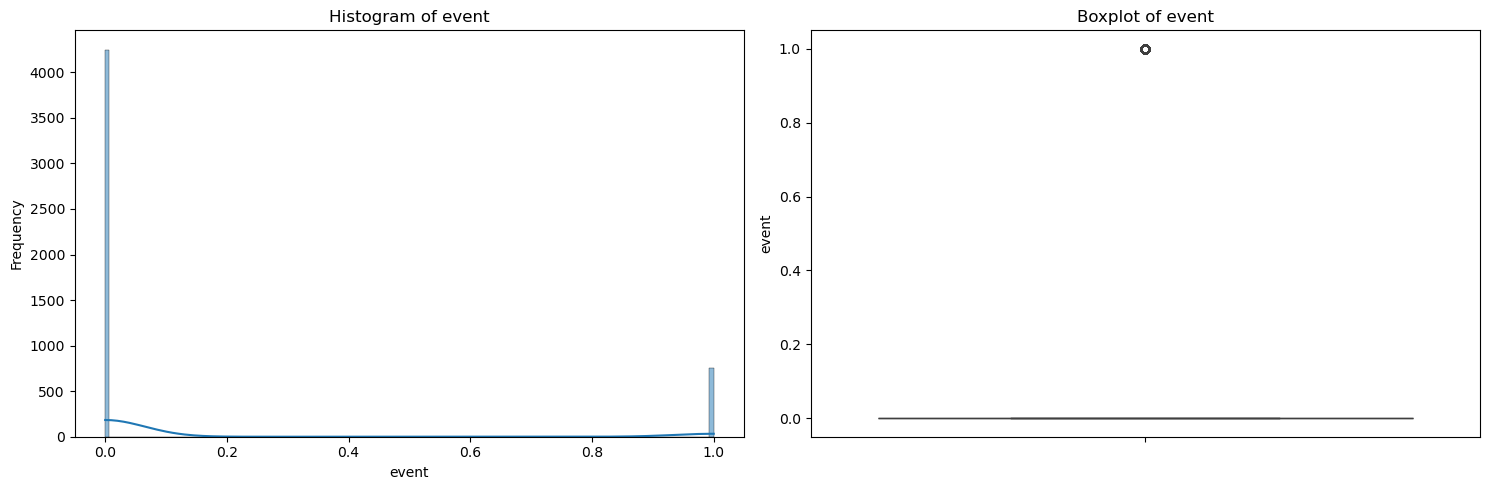

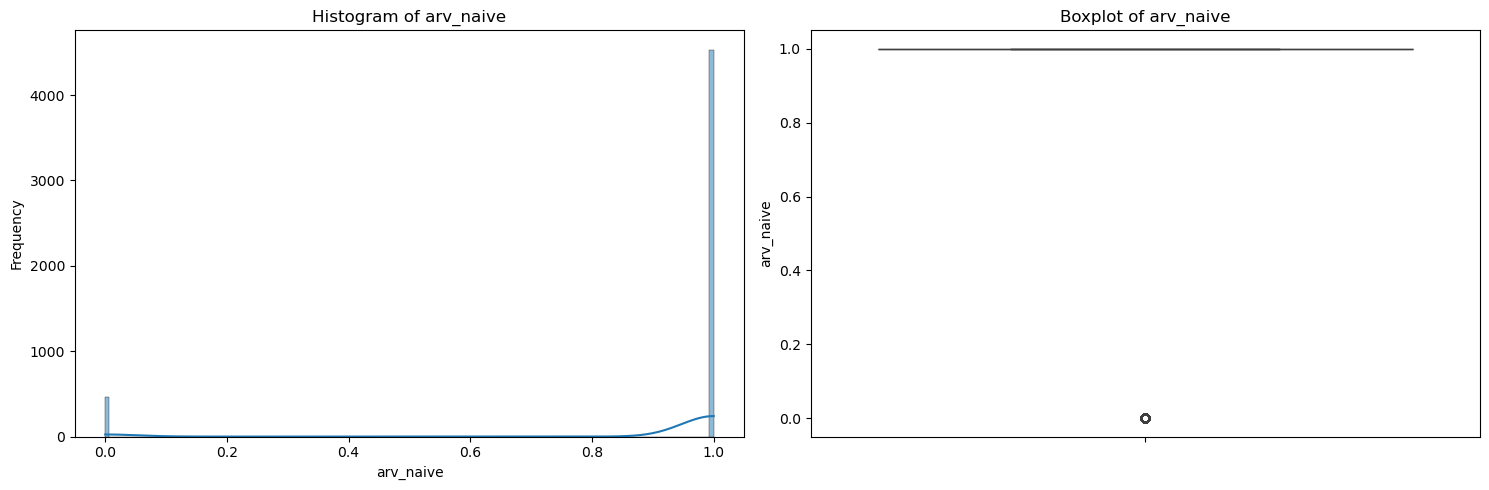

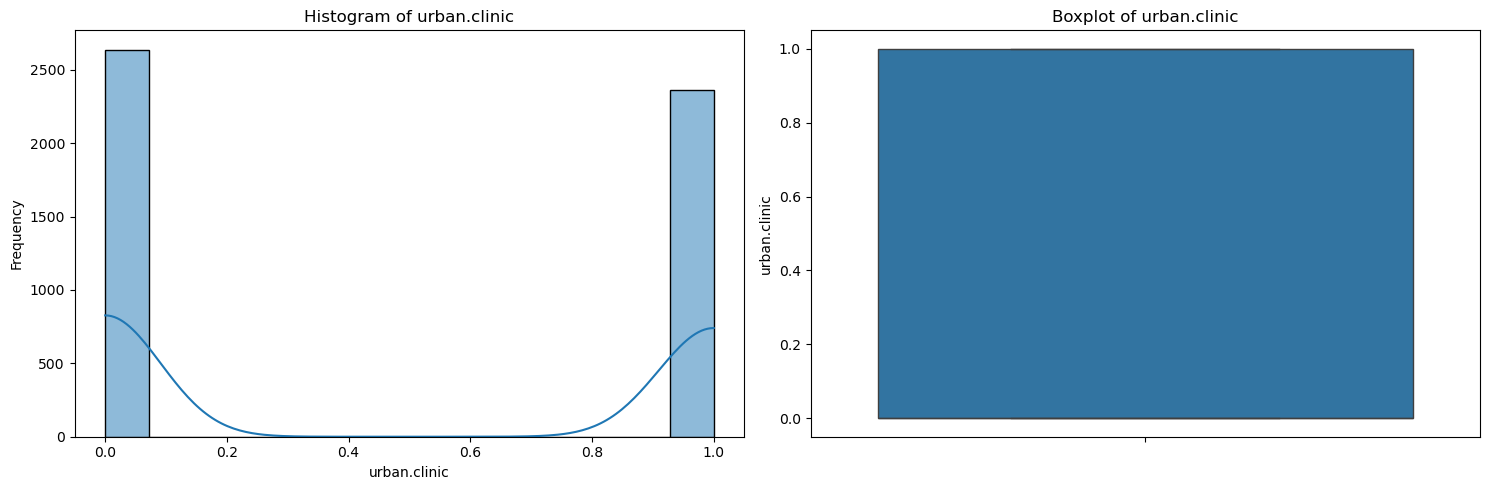

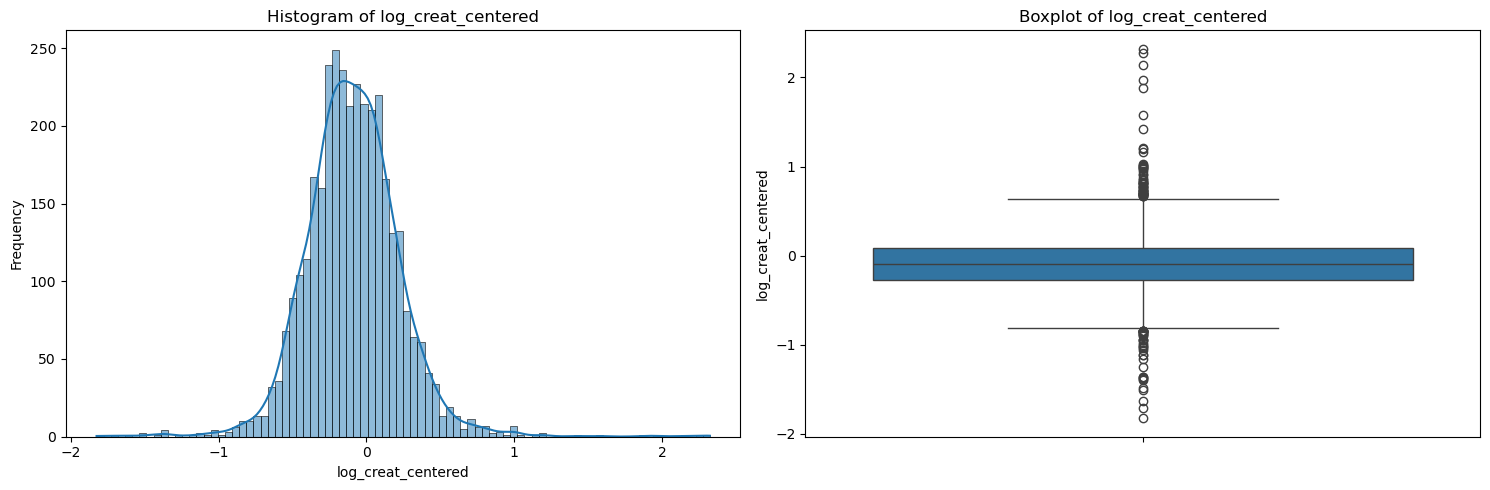

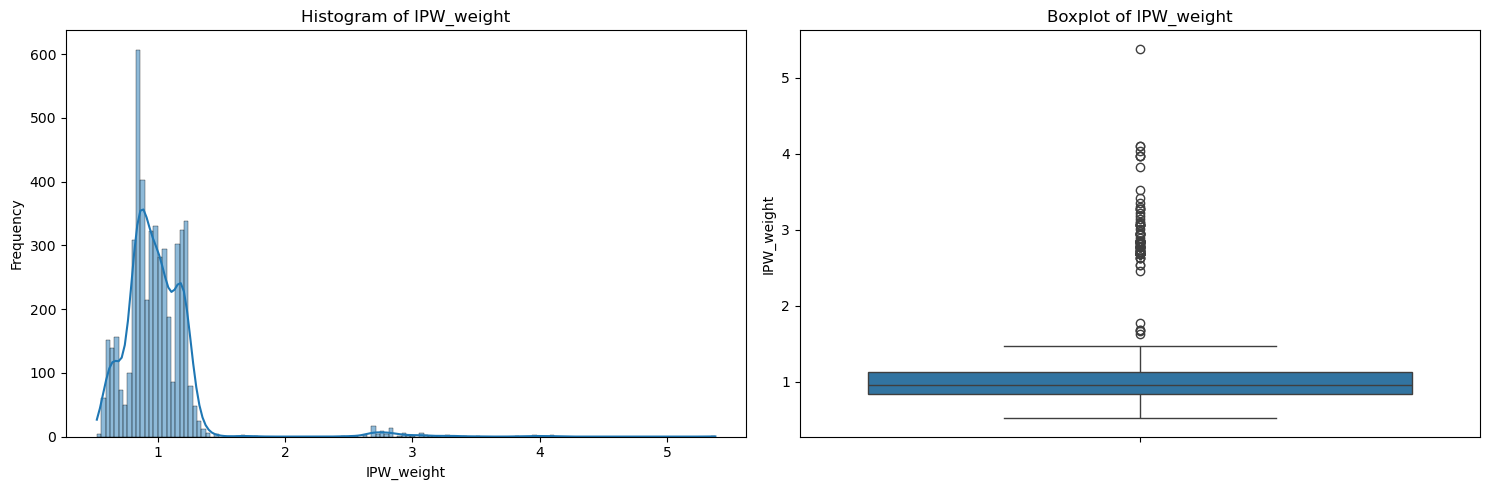

In [70]:
# Select numerical columns, excluding 'ID' and the target variable 'SBP_ge120'
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['ID', 'SBP_ge120']]

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    # Interpretation: Histograms show the shape of the distribution (e.g., normal, skewed, multimodal), central tendency, and spread.

    # Boxplot
    sns.boxplot(y=df[col].dropna(), ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_ylabel(col)
    # Interpretation: Boxplots reveal the median, interquartile range, and potential outliers. They are useful for identifying skewness and spread.

    plt.tight_layout()
    plt.show()


#### **1.4 Correlation Matrix Heatmap**

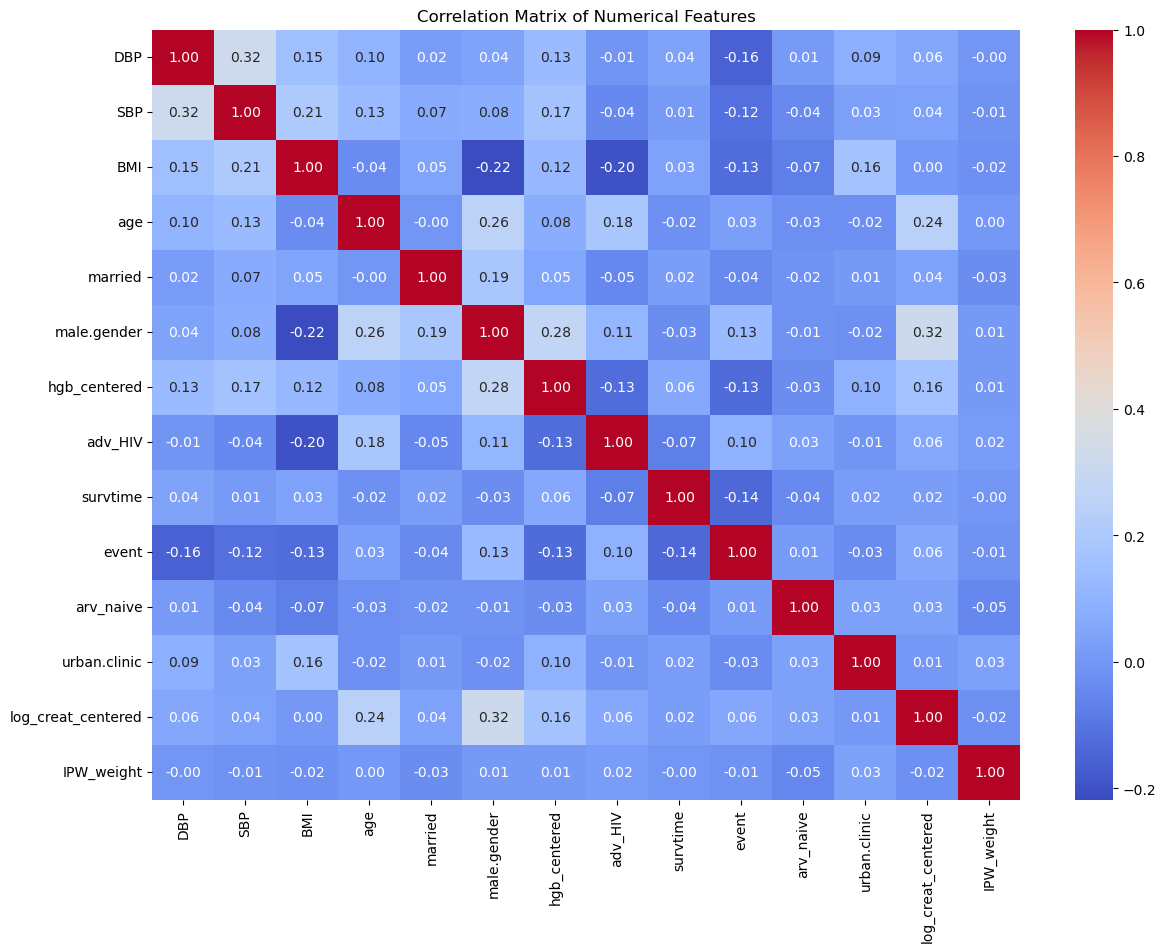

In [71]:
plt.figure(figsize=(14, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
# Interpretation: This heatmap shows the pairwise correlation coefficients between numerical features. Positive values (warm colors) indicate a positive correlation, negative values (cool colors) indicate a negative correlation, and values close to zero suggest little to no linear relationship. The intensity of the color and the absolute value of the coefficient indicate the strength of the correlation.
plt.show()

### **b.i) Class Distribution and Imbalance Ratio**

In [72]:
# Calculate class distribution
class_distribution = df['SBP_ge120'].value_counts()
print(f"\nClass Distribution of SBP_ge120:\n{class_distribution}")

# Interpretation: This shows the number of samples in each class (0 and 1) of the target variable.

# Calculate imbalance ratio
minority_class_count = class_distribution.min()
majority_class_count = class_distribution.max()
imbalance_ratio = majority_class_count / minority_class_count

print(f"\nImbalance Ratio (Majority Class / Minority Class): {imbalance_ratio:.2f}")
# Interpretation: An imbalance ratio significantly greater than 1 indicates class imbalance. A high ratio suggests that the model might be biased towards the majority class if not handled appropriately.
# Why imbalance matters for modeling and metric selection: Class imbalance can lead to models that perform poorly on the minority class because they are optimized for the majority class. Traditional metrics like accuracy can be misleading in imbalanced datasets. Therefore, metrics like precision, recall, F1-score, AUC-ROC, and AUPRC (Area Under the Precision-Recall Curve) are often more appropriate for evaluating models on imbalanced data, and techniques like oversampling, undersampling, or using algorithms designed for imbalanced data (e.g., SMOTE) might be necessary.


Class Distribution of SBP_ge120:
SBP_ge120
0    4749
1     250
Name: count, dtype: int64

Imbalance Ratio (Majority Class / Minority Class): 19.00


### **b.ii) . Handling Missing Values**

In [73]:
# Identify columns with missing values and their types
missing_numerical_cols = ['BMI', 'hgb_centered', 'log_creat_centered']
missing_categorical_cols = ['married', 'adv_HIV']

# Impute missing numerical values with the median
for col in missing_numerical_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

# Impute missing categorical values with the mode
for col in missing_categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # .mode() can return multiple if frequencies are tied
        df[col].fillna(mode_val, inplace=True)
        print(f"Missing values in '{col}' imputed with mode: {mode_val}")

# Verify that there are no more missing values in the imputed columns
print("\nVerifying missing values after imputation:")
print(df[missing_numerical_cols + missing_categorical_cols].isnull().sum())

# Display the first few rows to show changes
print("\nDataFrame head after imputation:")
display(df.head())

Missing values in 'BMI' imputed with median: 20.8359585
Missing values in 'hgb_centered' imputed with median: 0.1000004
Missing values in 'log_creat_centered' imputed with median: -0.0963537
Missing values in 'married' imputed with mode: 1.0
Missing values in 'adv_HIV' imputed with mode: 1.0

Verifying missing values after imputation:
BMI                   0
hgb_centered          0
log_creat_centered    0
married               0
adv_HIV               0
dtype: int64

DataFrame head after imputation:


,ID,DBP,SBP,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,SBP_ge120
0,16097,60,90,20.835959,28.000000,0.0,0,0.1,1.0,338,1,1,0,-9.635370e-02,0.924379,0
1,930,75,110,27.339912,26.458590,1.0,0,-3.9,0.0,439,1,1,1,5.421770e-02,1.163862,0
2,6877,60,80,17.689789,42.951405,0.0,0,-3.2,1.0,752,1,1,0,-3.597409e-01,0.721148,0
3,36464,60,90,19.854080,50.149212,1.0,1,0.1,1.0,526,1,1,1,-9.635370e-02,0.829452,0
4,36180,60,100,21.295294,30.554415,0.0,1,-0.4,1.0,215,1,1,0,-1.000000e-07,0.856046,0


### **b.iii) Encoding Categorical/Binary Variables**

In [74]:
# List of binary columns that might be float after imputation and should be integer
binary_float_cols = ['married', 'adv_HIV']

# Convert these columns to integer type (e.g., int8 for memory efficiency)
for col in binary_float_cols:
    if col in df.columns:
        df[col] = df[col].astype('int8')
        print(f"Converted '{col}' to int8 type.")

print("\nAll other binary/categorical variables are already in numerical (0/1) format and compatible with scikit-learn.")

# Display updated data types to confirm changes
print("\nUpdated data types for relevant columns:")
print(df[['married', 'adv_HIV', 'male.gender', 'event', 'arv_naive', 'urban.clinic', 'SBP_ge120']].dtypes)

# Display the first few rows to show changes
print("\nDataFrame head after encoding/type conversion:")
display(df.head())

Converted 'married' to int8 type.
Converted 'adv_HIV' to int8 type.

All other binary/categorical variables are already in numerical (0/1) format and compatible with scikit-learn.

Updated data types for relevant columns:
married          int8
adv_HIV          int8
male.gender     int64
event           int64
arv_naive       int64
urban.clinic    int64
SBP_ge120       int64
dtype: object

DataFrame head after encoding/type conversion:


,ID,DBP,SBP,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,SBP_ge120
0,16097,60,90,20.835959,28.000000,0,0,0.1,1,338,1,1,0,-9.635370e-02,0.924379,0
1,930,75,110,27.339912,26.458590,1,0,-3.9,0,439,1,1,1,5.421770e-02,1.163862,0
2,6877,60,80,17.689789,42.951405,0,0,-3.2,1,752,1,1,0,-3.597409e-01,0.721148,0
3,36464,60,90,19.854080,50.149212,1,1,0.1,1,526,1,1,1,-9.635370e-02,0.829452,0
4,36180,60,100,21.295294,30.554415,0,1,-0.4,1,215,1,1,0,-1.000000e-07,0.856046,0


## **C2. Model Development Strategy**

### **a) Split of the preprocessed data into training and testing sets**

#### **a.i) Split ratio**

In [75]:
# Define features (X) and target (y)
X = df.drop(columns=['ID', 'IPW_weight', 'SBP_ge120'])
y = df['SBP_ge120']

# Split the data into training and testing sets using only a 70/30 ratio
# Note: This split does NOT include stratified sampling or a fixed random state.
# As a result, the distribution of the target variable in training and test sets may vary, and results will not be reproducible across runs.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print(f"Original dataset shape: {df.shape}")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nTraining set features (X_train) shape: {X_train.shape}")
print(f"Training set target (y_train) shape: {y_train.shape}")
print(f"Testing set features (X_test) shape: {X_test.shape}")
print(f"Testing set target (y_test) shape: {y_test.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in training set (Split ratio):")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in testing set (Split ratio):")
print(y_test.value_counts(normalize=True))

Original dataset shape: (4999, 16)
Features (X) shape: (4999, 13)
Target (y) shape: (4999,)

Training set features (X_train) shape: (3499, 13)
Training set target (y_train) shape: (3499,)
Testing set features (X_test) shape: (1500, 13)
Testing set target (y_test) shape: (1500,)

Class distribution in original data:
SBP_ge120
0    0.94999
1    0.05001
Name: proportion, dtype: float64

Class distribution in training set (Split ratio):
SBP_ge120
0    0.947128
1    0.052872
Name: proportion, dtype: float64

Class distribution in testing set (Split ratio):
SBP_ge120
0    0.956667
1    0.043333
Name: proportion, dtype: float64


#### **a.ii) Stratified Sampling**

In [76]:
# Define features (X) and target (y) again for clarity in this separate example
X = df.drop(columns=['ID', 'IPW_weight', 'SBP_ge120'])
y = df['SBP_ge120']

# Split the data into training and testing sets using stratified sampling
# Justification:
# 1. `stratify=y`: This is the core of stratified sampling. It ensures that the proportion of the target variable ('SBP_ge120') is maintained in both the training and testing sets.
#    This is particularly important for imbalanced datasets, preventing scenarios where the minority class might be under-represented or completely absent in a subset.
# 2. `test_size=0.3`: A split ratio is still required for train_test_split. We'll use 30% for testing.
# 3. `random_state` is INTENTIONALLY OMITTED here to demonstrate that without it, the split will vary on each execution.
X_train_stratified, X_test_stratified, y_train_stratified, y_test_stratified = train_test_split(X, y, test_size=0.3, stratify=y)

print(f"Original dataset shape: {df.shape}")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nTraining set features (X_train_stratified) shape: {X_train_stratified.shape}")
print(f"Training set target (y_train_stratified) shape: {y_train_stratified.shape}")
print(f"Testing set features (X_test_stratified) shape: {X_test_stratified.shape}")
print(f"Testing set target (y_test_stratified) shape: {y_test_stratified.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in training set (stratified):")
print(y_train_stratified.value_counts(normalize=True))
print("\nClass distribution in testing set (stratified):")
print(y_test_stratified.value_counts(normalize=True))

Original dataset shape: (4999, 16)
Features (X) shape: (4999, 13)
Target (y) shape: (4999,)

Training set features (X_train_stratified) shape: (3499, 13)
Training set target (y_train_stratified) shape: (3499,)
Testing set features (X_test_stratified) shape: (1500, 13)
Testing set target (y_test_stratified) shape: (1500,)

Class distribution in original data:
SBP_ge120
0    0.94999
1    0.05001
Name: proportion, dtype: float64

Class distribution in training set (stratified):
SBP_ge120
0    0.949986
1    0.050014
Name: proportion, dtype: float64

Class distribution in testing set (stratified):
SBP_ge120
0    0.95
1    0.05
Name: proportion, dtype: float64


#### **a.iii) Fixed Random State for Reproducibility**

In [77]:
X = df.drop(columns=['ID', 'IPW_weight', 'SBP_ge120'])
y = df['SBP_ge120']

# Split the data into training and testing sets with a fixed random state and stratification
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

print(f"Original dataset shape: {df.shape}")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nTraining set features (X_train_final) shape: {X_train_final.shape}")
print(f"Training set target (y_train_final) shape: {y_train_final.shape}")
print(f"Testing set features (X_test_final) shape: {X_test_final.shape}")
print(f"Testing set target (y_test_final) shape: {y_test_final.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in training set (stratified and reproducible):")
print(y_train_final.value_counts(normalize=True))
print("\nClass distribution in testing set (stratified and reproducible):")
print(y_test_final.value_counts(normalize=True))

# Justification of choices:
# 1. `test_size=0.3`: Allocates 30% of the data to the test set, balancing between sufficient training data and a representative test set.
# 2. `stratify=y`: Ensures that the proportion of the target variable (`SBP_ge120`) is maintained across both training and testing sets.
#    This is critical for imbalanced datasets, preventing a scenario where the minority class might be poorly represented or absent in either set, which would lead to biased model evaluation.
# 3. `random_state=42`: Fixes the seed for the random number generator used in the split. This makes the split entirely reproducible, meaning that if you run the code again with the same random_state, you will get the exact same training and testing sets. This is essential for consistent experimentation and debugging.

Original dataset shape: (4999, 16)
Features (X) shape: (4999, 13)
Target (y) shape: (4999,)

Training set features (X_train_final) shape: (3499, 13)
Training set target (y_train_final) shape: (3499,)
Testing set features (X_test_final) shape: (1500, 13)
Testing set target (y_test_final) shape: (1500,)

Class distribution in original data:
SBP_ge120
0    0.94999
1    0.05001
Name: proportion, dtype: float64

Class distribution in training set (stratified and reproducible):
SBP_ge120
0    0.949986
1    0.050014
Name: proportion, dtype: float64

Class distribution in testing set (stratified and reproducible):
SBP_ge120
0    0.95
1    0.05
Name: proportion, dtype: float64


### **b) Model Pipelines and Training**


In [78]:
def imputer():
    return SimpleImputer(strategy='median')

#### **b.i) Logistic Regression Pipeline**

In [79]:
# 1. Logistic Regression
print("\n--- Training Logistic Regression Model ---")
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Scaling is required for regularization in Logistic Regression
    ('classifier', LogisticRegression(random_state=42, solver='liblinear', C=0.1)) # C is the inverse of regularization strength, solver for algorithm choice
])

# Train the model
log_reg_pipeline.fit(X_train_final, y_train_final)
print("Logistic Regression model trained successfully.")

# Justification of choices:
# (1) Scaling is required: Logistic Regression often uses regularization (L1 or L2) to prevent overfitting. Regularization penalties are applied to the coefficients, and if features are on different scales, features with larger scales will have a disproportionately larger impact on the penalty. StandardScaler ensures all features contribute equally to the regularization term.
# (2) Practical Advantage for Hypertension Prediction: Provides interpretable coefficients (log-odds ratios), which can be valuable for clinicians to understand which factors are most strongly associated with SBP >= 120 and in what direction.
# (3) Limitation for Hypertension Prediction: Assumes a linear relationship between the features and the log-odds of hypertension. If the underlying biological relationships are complex and non-linear, Logistic Regression might underperform compared to more flexible models.


--- Training Logistic Regression Model ---
Logistic Regression model trained successfully.


#### **b.ii) K-Nearest Neighbors (KNN) Pipeline**

In [80]:
# 2. K-Nearest Neighbors (KNN)
print("\n--- Training K-Nearest Neighbors Model ---")
knn_model = Pipeline([
    ('scaler', StandardScaler()), # Scaling is required for distance-based algorithms like KNN
    ('classifier', KNeighborsClassifier(n_neighbors=5, weights='distance')) # n_neighbors (k value), weights (uniform or distance)
])

# Train the model
knn_pipeline.fit(X_train_final, y_train_final)
print("K-Nearest Neighbors model trained successfully.")

# Justification of choices:
# (1) Scaling is required: KNN classifies data points based on the distance to their neighbors. Features with larger numerical ranges would disproportionately influence the distance calculations. StandardScaler normalizes feature ranges, ensuring all features contribute equally to the distance metric.
# (2) Practical Advantage for Hypertension Prediction: Can capture complex, non-linear relationships and local patterns in the data without making strong assumptions about the underlying distribution, potentially identifying subtle patient groups at risk.
# (3) Limitation for Hypertension Prediction: Can be computationally expensive for large datasets during prediction (as it needs to calculate distances to all training samples). It can also be sensitive to irrelevant features or noise, which might obscure true relationships if not handled through feature selection.


--- Training K-Nearest Neighbors Model ---
K-Nearest Neighbors model trained successfully.


#### **b.iii) Support Vector Machine (SVM) Pipeline**

In [81]:
# 3. Support Vector Machine (SVM)
print("\n--- Training Support Vector Machine Model ---")
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Scaling is required for SVM
    ('classifier', SVC(random_state=42, kernel='rbf', C=1.0, probability=True)) # kernel type, C (regularization parameter)
])

# Train the model
svm_pipeline.fit(X_train_final, y_train_final)
print("Support Vector Machine model trained successfully.")

# Justification of choices:
# (1) Scaling is required: SVMs aim to find an optimal hyperplane that maximizes the margin between classes. Features with larger magnitudes can dominate the distance calculations and influence the hyperplane disproportionately. StandardScaler ensures each feature contributes appropriately to the margin optimization.
# (2) Practical Advantage for Hypertension Prediction: Effective in high-dimensional spaces and can model complex decision boundaries, potentially leading to accurate predictions even when hypertension risk factors interact in non-linear ways.
# (3) Limitation: The model has limited interpretability compared to simpler methods such as Logistic Regression.


--- Training Support Vector Machine Model ---
Support Vector Machine model trained successfully.


#### **b.iv) Random Forest Classifier Pipeline**

In [82]:
# 4. Random Forest Classifier
print("\n--- Training Random Forest Classifier ---")
rand_forest_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Scaling is not strictly required for Random Forest but can sometimes subtly improve performance with certain implementations or for consistency across a pipeline.
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)) # n_estimators (number of trees), max_depth (tree depth)
])

# Train the model
rand_forest_pipeline.fit(X_train_final, y_train_final)
print("Random Forest Classifier model trained successfully.")

# Justification of choices:
# (1) Scaling: Random Forest does not require feature scaling, but StandardScaler ensures consistency across models.
# (2) Advantage: It provides strong predictive accuracy, robustness to overfitting, and identifies important hypertension risk factors.
# (3) Limitation: The model has limited interpretability compared to simpler methods such as Logistic Regression.


--- Training Random Forest Classifier ---
Random Forest Classifier model trained successfully.


In [83]:
print("""for model in [log_reg_pipeline, knn_pipeline, svm_pipeline, rand_forest_pipeline]:
    model.fit(X_train_final, y_train_final)

models = {
    'Logistic Regression Model':    log_reg_pipeline,
    'K-Nearest Neighbors Model':   knn_pipeline,
    'Support Vector Machine Mode': svm_pipeline,
    'Random Forest Classifier':          rand_forest_pipeline
}""")

for model in [log_reg_pipeline, knn_pipeline, svm_pipeline, rand_forest_pipeline]:
    model.fit(X_train_final, y_train_final)

models = {
    'Logistic Regression Model':    log_reg_pipeline,
    'K-Nearest Neighbors Model':   knn_pipeline,
    'Support Vector Machine Mode': svm_pipeline,
    'Random Forest Classifier':          rand_forest_pipeline
}


## **C3. Model Evaluation and Comparison**

In [84]:
def evaluate_predictive_performance():
    print("=" * 65)
    print("C4(b)(i): PREDICTIVE PERFORMANCE — AUC AND GENERALISATION")
    print("=" * 65)
 
    # Test set AUC
    lr_test_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1])
    rf_test_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
 
    # Cross-validated AUC
    lr_cv = cross_val_score(lr_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    rf_cv = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
 
    # Additional metrics
    lr_recall = recall_score(y_test, lr_model.predict(X_test), zero_division=0)
    rf_recall = recall_score(y_test, rf_model.predict(X_test), zero_division=0)
    lr_f1     = f1_score(y_test, lr_model.predict(X_test), zero_division=0)
    rf_f1     = f1_score(y_test, rf_model.predict(X_test), zero_division=0)
 
    perf_df = pd.DataFrame({
        'Metric': [
            'Test ROC-AUC',
            'CV ROC-AUC (Mean)',
            'CV ROC-AUC (Std Dev ±)',
            'Recall / Sensitivity',
            'F1-Score'
        ],
        'Logistic Regression': [
            f'{lr_test_auc:.4f}',
            f'{lr_cv.mean():.4f}',
            f'{lr_cv.std():.4f}',
            f'{lr_recall:.4f}',
            f'{lr_f1:.4f}'
        ],
        'Random Forest': [
            f'{rf_test_auc:.4f}',
            f'{rf_cv.mean():.4f}',
            f'{rf_cv.std():.4f}',
            f'{rf_recall:.4f}',
            f'{rf_f1:.4f}'
        ]
    }).set_index('Metric')
 
    print(perf_df.to_string())
 
    print("""
INTERPRETATION:
  Random Forest achieves a higher Test AUC (0.766 vs 0.690) and a
  higher CV AUC (0.737 vs 0.698), indicating it is the stronger
  discriminator across all decision thresholds.
 
  However, both models produce near-zero Recall — meaning almost no
  true high-risk patients are being correctly identified at the
  default threshold. This is a direct consequence of the severe class
  imbalance (~5% positive cases). Neither model is safe for clinical
  deployment without first addressing this imbalance (e.g. using
  class_weight='balanced' and lowering the decision threshold).
 
  The AUC gap between models (~0.04 on CV) is modest and does not
  alone justify choosing Random Forest given its higher complexity.
""")